# Land Use prediction

In [ ]:
import pandas as pd
blocks_gdf = pd.read_pickle('./../../data/saint_petersburg/blocks.pickle')

In [ ]:
from blocksnet.analysis.land_use.prediction import SpatialClassifier

In [ ]:
classifier = SpatialClassifier.default()
result = classifier.run(blocks_gdf)

In [ ]:
result

# Land Use Train Mode

In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import os
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from blocksnet.analysis.land_use.prediction import SpatialClassifier
from blocksnet.machine_learning.strategy.sklearn.ensemble.voting.classification_strategy import SKLearnVotingClassificationStrategy

d:\programming\github\blocksnet\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import pandas as pd
blocks_gdf = pd.read_pickle('./../../data/saint_petersburg/blocks.pickle')

In [2]:
import pickle
import pandas as pd
import geopandas as gpd
from pathlib import Path

def load_gdfs(root: str | Path, pattern: str = "*.pkl", target_crs: str | None = None) -> list[gpd.GeoDataFrame]:
    """
    Загружает GeoDataFrame'ы из .pkl файлов:
      - если root указывает на один .pkl файл — читаем его и возвращаем список [GDF]
      - если root — папка — рекурсивно ищем по маске pattern и возвращаем список GDF

    Пытаемся заполнить столбцы 'city' и 'country' из структуры путей:
    .../<country>/<city>/<file>.pkl

    Args:
        root: путь к файлу .pkl или папке
        pattern: маска файлов (по умолчанию "*.pkl") — используется только если root папка
        target_crs: если указан, приводим все геоданные к этому CRS

    Returns:
        list[GeoDataFrame]
    """
    p = Path(root)

    def _ensure_gdf(obj):
        """Преобразует объект в GeoDataFrame, если это DataFrame с колонкой 'geometry'."""
        if isinstance(obj, gpd.GeoDataFrame):
            return obj
        if isinstance(obj, pd.DataFrame) and "geometry" in obj.columns:
            return gpd.GeoDataFrame(obj, geometry="geometry", crs=getattr(obj, "crs", None))
        return None

    def _infer_city_country(fp: Path):
        # ожидаем .../<country>/<city>/<file>.pkl
        city = fp.name[:-4] if fp else None
        country = fp.parent.name if len(fp.parents) >= 2 else None
        return city, country

    # Соберём список файлов
    if p.is_file() and p.suffix.lower() == ".pkl":
        files = [p]
    elif p.is_dir():
        files = sorted(p.rglob(pattern))
        files = [f for f in files if f.suffix.lower() == ".pkl"]
    else:
        return []

    gdfs: list[gpd.GeoDataFrame] = []

    for fp in files:
        try:
            with open(fp, "rb") as f:
                obj = pickle.load(f)
        except Exception as e:
            print(f"Пропускаю {fp}: {e}")
            continue

        # Если GeoDataFrame
        gdf = _ensure_gdf(obj)

        # Если dict с GeoDataFrame
        if gdf is None and isinstance(obj, dict):
            for k, v in obj.items():
                gi = _ensure_gdf(v)
                if gi is None:
                    continue
                gi = gi.copy()
                if "city" not in gi.columns or gi["city"].isna().all():
                    gi["city"] = str(k)
                _, country = _infer_city_country(fp)
                if ("country" not in gi.columns) and country:
                    gi["country"] = country
                if target_crs:
                    gi = gi.to_crs(target_crs) if gi.crs else gi.set_crs(target_crs)
                gdfs.append(gi)
            continue

        if gdf is None:
            print(f"Пропускаю {fp}: объект не GeoDataFrame и не dict с GeoDataFrame.")
            continue

        gdf = gdf.copy()
        city, country = _infer_city_country(fp)
        if "city" not in gdf.columns:
            gdf["city"] = city or fp.stem
        if ("country" not in gdf.columns) and country:
            gdf["country"] = country

        if target_crs:
            gdf = gdf.to_crs(target_crs) if gdf.crs else gdf.set_crs(target_crs)

        gdfs.append(gdf)

    return gdfs

blocks_gdf = load_gdfs('data/TANYA-2025/Russia')

In [ ]:
from blocksnet.analysis.land_use.prediction.core import str_to_land_use, land_use_to_category

# def map_and_filter_blocks(blocks):
    # out = []
    # for g in blocks:
    #     gi = g.copy()
    #     gi["category"] = gi["land_use"].map(str_to_land_use).map(land_use_to_category)
    #     if gi["category"].notna().sum() > 99:
    #         out.append(g)
    # return out

# blocks_gdf = map_and_filter_blocks(blocks_gdf)

In [3]:
from blocksnet.analysis.land_use.prediction.core import str_to_land_use, land_use_to_category, category_to_index
from blocksnet.analysis.land_use.prediction.schemas import BlocksInputSchema
import pandas as pd

def normalize_and_filter(data):
    if isinstance(data, (list, tuple)):
        out = []
        for g in data:
            
            gi = BlocksInputSchema(g)
            if 'land_use' in gi:
                gi['category'] = gi['land_use'].map(str_to_land_use).map(land_use_to_category)
            gi = gi[gi['category'].map(category_to_index).notna()]
            if not gi.empty:
                out.append(gi)
        return out
    else:
        g = BlocksInputSchema(data)
        if 'land_use' in g:
            g['category'] = g['land_use'].map(str_to_land_use).map(land_use_to_category)
        return g[g['category'].map(category_to_index).notna()]

blocks_gdf = normalize_and_filter(blocks_gdf)
len(blocks_gdf), 

(161,)

In [16]:
blocks_gdf[3]['category'].value_counts()

category
LandUseCategory.LIVING        424
LandUseCategory.NOT_LIVING    382
Name: count, dtype: int64

In [17]:
pd.concat(blocks_gdf)['category'].value_counts(), pd.concat(blocks_gdf)['category'].value_counts() / pd.concat(blocks_gdf).shape[0]

(category
 LandUseCategory.LIVING        133919
 LandUseCategory.NOT_LIVING     73917
 Name: count, dtype: int64,
 category
 LandUseCategory.LIVING        0.644349
 LandUseCategory.NOT_LIVING    0.355651
 Name: count, dtype: float64)

In [5]:
import pandas as pd
from typing import List, Any

def filter_balanced_cities(
    gdfs: List[pd.DataFrame],
    category_col: str = 'category',
    target_percent: float = 25.0,
    tolerance: float = 10.0,
    required_count: int = 4
) -> List[pd.DataFrame]:
    """
    Фильтрует список датафреймов (городов), оставляя только те,
    где все `required_count` типов из Enum присутствуют и их доля 
    близка к target_percent ± tolerance.

    :param gdfs: Список DataFrame/GeoDataFrame (по одному на город)
    :param category_col: Название колонки с Enum
    :param target_percent: Целевой процент для каждого класса (25%)
    :param tolerance: Допуск в процентах (±10% → от 15% до 35%)
    :param required_count: Количество обязательных уникальных типов (например, 4)
    :return: Отфильтрованный список датафреймов
    """
    lower_bound = target_percent - tolerance  # 15%
    upper_bound = target_percent + tolerance  # 35%
    filtered_gdfs = []

    for i, gdf in enumerate(gdfs):
        if gdf.empty or category_col not in gdf.columns:
            continue

        # Преобразуем Enum в строку по .name
        cat_names = gdf[category_col].apply(lambda x: x.name if hasattr(x, 'name') else str(x))
        
        # Проверяем, что все 4 типа присутствуют
        unique_categories = cat_names.unique()
        if len(unique_categories) < required_count:
            continue  # не хватает типов

        # Считаем доли
        value_counts = cat_names.value_counts(normalize=True) * 100  # в процентах

        # Проверяем, что каждый класс в диапазоне [lower_bound, upper_bound]
        all_within_range = True
        for cat, pct in value_counts.items():
            if not (lower_bound <= pct <= upper_bound):
                all_within_range = False
                break

        if all_within_range:
            filtered_gdfs.append(gdf)

    return filtered_gdfs

In [12]:
# Предположим, у вас есть list_of_city_gdfs — список GDF по городам
tolerance = 25
filtered_cities = filter_balanced_cities(blocks_gdf, required_count=2, tolerance=tolerance)

print(f"Найдено {len(filtered_cities)} городов с равномерным распределением (25% ± {tolerance}%)")

Найдено 0 городов с равномерным распределением (25% ± 25%)


In [10]:
filtered_cities[0]

,geometry,category
0,"POLYGON ((4163187.242 7502039.241, 4163220.671...",LandUseCategory.LARGE_AREA
1,"POLYGON ((4163187.242 7502039.241, 4163039.287...",LandUseCategory.MIXED_USE
2,"POLYGON ((4163249.124 7503677.414, 4163260.702...",LandUseCategory.MIXED_USE
3,"POLYGON ((4163018.359 7502392.456, 4163072.538...",LandUseCategory.MIXED_USE
4,"POLYGON ((4163404.471 7499122.693, 4163391.101...",LandUseCategory.LARGE_AREA
...,...,...
9853,"POLYGON ((4195757.989 7493610.36, 4195778.06 7...",LandUseCategory.LARGE_AREA
9854,"POLYGON ((4164552.197 7514044.169, 4164541.009...",LandUseCategory.MIXED_USE
9855,"POLYGON ((4193483.465 7510198.489, 4193483.465...",LandUseCategory.LARGE_AREA
9856,"POLYGON ((4194191.434 7482568.072, 4194174.647...",LandUseCategory.LARGE_AREA


In [18]:
# 1. Инициализация и обучение
BASE_PARAMS = {"random_state": 42, "n_jobs": -1}
CPU = max(1, min(8, os.cpu_count() or 1))
MODEL_PARAMS = {
    "rf": {
        "n_estimators": 120,          # было 200
        "max_depth": 7,
        "class_weight": "balanced",
        "max_samples": 0.25,          # 🔴 бэггинг на подвыборке
        "min_samples_leaf": 10,       # стабилизация и меньше узлов
        **BASE_PARAMS
    },
    "xgb": {
        "n_estimators": 150,          # меньше
        "max_depth": 7,
        "learning_rate": 0.05,
        "subsample": 0.8,             # стахастичность
        "colsample_bytree": 0.8,
        "tree_method": "hist",        # память/скорость
        "n_jobs": CPU                 # XGB игнорирует BASE_PARAMS если его стерли
    },
    "lgb": {
        "n_estimators": 200,
        "max_depth": 7,
        "learning_rate": 0.05,
        "class_weight": "balanced",
        "num_threads": CPU            # у LGB параметр другое имя
    },
    "hgb": {
        "max_iter": 200,
        "max_depth": 7,
        "learning_rate": 0.05,
        "random_state": 42
    }
}
estimators = [
    ("rf",  RandomForestClassifier(**MODEL_PARAMS["rf"])),
    ("xgb", XGBClassifier(**MODEL_PARAMS["xgb"])),
    ("lgb", LGBMClassifier(**MODEL_PARAMS["lgb"])),
    ("hgb", HistGradientBoostingClassifier(**MODEL_PARAMS["hgb"])),
]

# estimators = [
# ("rf", RandomForestClassifier(n_estimators=400, max_depth=12, min_samples_leaf=5, class_weight="balanced", random_state=42, n_jobs=-1)),
# ("xgb", XGBClassifier(n_estimators=600, max_depth=8, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, tree_method="hist", n_jobs=8)),
# ("lgb", LGBMClassifier(n_estimators=800, max_depth=10, learning_rate=0.05, class_weight="balanced", num_threads=8)),
# ("hgb", HistGradientBoostingClassifier(max_iter=500, max_depth=8, learning_rate=0.05, random_state=42)),
# ]

strategy = SKLearnVotingClassificationStrategy(estimators, {"voting": "soft", "n_jobs": -1})
classifier = SpatialClassifier(strategy, 1000, 5)


In [144]:
import pandas as pd
from typing import List
from tqdm import tqdm

def balance_dfs_by_category(dfs: List[pd.DataFrame]) -> List[pd.DataFrame]:
    """
    Балансирует каждый DataFrame: 
    - целевой размер = min_count * 2, 
    - но не больше max_count (чтобы не делать oversampling)
    Затем undersample всех классов до этого целевого размера (если возможно).
    
    :param dfs: Список DataFrame или GeoDataFrame
    :return: Список сбалансированных DataFrame
    """
    balanced_dfs = []
    
    for df in tqdm(dfs):
        if df.empty:
            balanced_dfs.append(df)
            continue
        
        if 'category' not in df.columns:
            raise ValueError("Один из DataFrame не содержит колонки 'category'")
        
        # Преобразуем Enum -> строка по .name
        cat_names = df['category'].apply(lambda x: x.name if hasattr(x, 'name') else str(x))
        
        counts = cat_names.value_counts()
        min_count = counts.min()
        max_count = counts.max()
        
        # Целевой размер: min * 2, но не больше max_count
        target_size = min(int(min_count * 1.2), max_count)
        
        # Группируем без сортировки
        grouped = df.groupby(cat_names, sort=False)
        
        # Пробуем взять target_size образцов из каждой группы
        # Если в группе меньше — берём всё (undersample только если больше)
        balanced_df = grouped.apply(
            lambda group: group.sample(
                n=min(len(group), target_size), 
                random_state=42, 
                replace=False
            ),
            include_groups=False
        ).reset_index(drop=True)
        
        balanced_dfs.append(balanced_df)
    
    return balanced_dfs

balanced_gdfs = balance_dfs_by_category(blocks_gdf)

100%|██████████| 156/156 [00:01<00:00, 134.97it/s]


In [ ]:
train_ready = classifier.preprocess_training_data(blocks_gdf)

In [149]:
train_ready.category.value_counts()

category
LandUseCategory.RESIDENTIAL    4128
LandUseCategory.RECREATION     4089
LandUseCategory.INDUSTRIAL     3957
LandUseCategory.BUSINESS       3337
Name: count, dtype: int64

In [150]:
score = classifier.train(train_ready)
score

d:\programming\github\blocksnet\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.6211681187479832

In [ ]:
for i in blocks_gdf:
    gdf = None
    print()
    if i.city[0] == 'Saint Petersburg':
        gdf = i
        break

In [151]:
raw_test = gpd.read_file('data/blocks_best_feature.gpkg')
test_ready = classifier.preprocess_run_data(raw_test)

In [152]:
result = classifier.run(test_ready)

d:\programming\github\blocksnet\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\programming\github\blocksnet\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


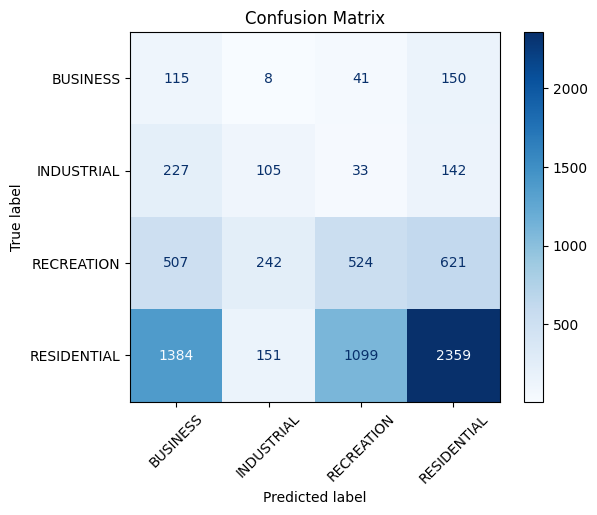

In [153]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Предположим, что result — это ваш DataFrame
true_labels = result[result.category.notna()]['category'].apply(lambda x: x.name)  # Извлекаем истинные метки
pred_labels = result[result.category.notna()]['pred_name']                        # Извлекаем предсказанные метки

# Строим матрицу ошибок
cm = confusion_matrix(true_labels, pred_labels)

# Визуализация
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(set(true_labels) | set(pred_labels)))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix')
plt.show()

In [154]:
# Получаем строковое представление (через .name), если это Enum
categories = train_ready['category'].apply(lambda x: x.name if hasattr(x, 'name') else str(x))

# Считаем количество
counts = categories.value_counts()

# Считаем проценты
percentages = (counts / counts.sum()) * 100

# Выводим результат
print("Распределение по категориям:")
print("----------------------------")
for category, count in counts.items():
    pct = percentages[category]
    print(f"{category:15} : {count:4} ({pct:.1f}%)")

result = pd.DataFrame({
    'Count': counts,
    'Percentage (%)': percentages.round(1)
})
result

Распределение по категориям:
----------------------------
RESIDENTIAL     : 4128 (26.6%)
RECREATION      : 4089 (26.4%)
INDUSTRIAL      : 3957 (25.5%)
BUSINESS        : 3337 (21.5%)


,Count,Percentage (%)
category,,
RESIDENTIAL,4128,26.6
RECREATION,4089,26.4
INDUSTRIAL,3957,25.5
BUSINESS,3337,21.5


In [36]:
import geopandas as gpd
import folium
from itertools import cycle

# gdf — ваш GeoDataFrame из примера
g = result[0].copy()

# Нормализация имён классов
def norm_cat(v):
    try:
        # Если это Enum LandUseCategory -> берём .value
        from blocksnet.enums import LandUseCategory
        if isinstance(v, LandUseCategory):
            return v.value
    except Exception:
        pass
    if isinstance(v, str):
        s = v.strip()
        # Строки вида "LandUseCategory.RESIDENTIAL" -> "RESIDENTIAL"
        if s.startswith("LandUseCategory."):
            return s.split(".", 1)[1]
        return s.upper()
    return str(v).upper()

g["category_name"] = g["category"].apply(norm_cat)
g["pred_name_norm"] = g["pred_name"].apply(norm_cat)

mism = g[g["category_name"] != g["pred_name_norm"]].copy()
if mism.empty:
    display("Нет несовпадений category и pred_name")
    mism  # Пустой набор на всякий случай
else:
    # Готовим CRS для folium (нужен EPSG:4326)
    if mism.crs is None and g.crs is not None:
        mism = mism.set_crs(g.crs, allow_override=True)
    if mism.crs is None:
        raise ValueError("GeoDataFrame должен иметь установленный CRS")
    mism_wgs = mism.to_crs(epsg=4326)

    # Центр карты
    minx, miny, maxx, maxy = mism_wgs.total_bounds
    center = [(miny + maxy) / 2, (minx + maxx) / 2]

    m = folium.Map(location=center, zoom_start=12, tiles="CartoDB positron")

    # Базовый слой с границами всех полигонов (опционально)
    try:
        all_wgs = g.to_crs(epsg=4326) if g.crs is not None else g
        all_wgs.explore(
            m=m,
            name="Все полигоны (контур)",
            style_kwds=dict(color="#999999", weight=1, fill=False),
            tooltip=False,
            show=False,
        )
    except Exception:
        pass

    # Палитра цветов для слоёв
    colors = cycle([
        "#e41a1c", "#377eb8", "#4daf4a", "#984ea3",
        "#ff7f00", "#ffff33", "#a65628", "#f781bf", "#999999"
    ])

    # Добавляем каждый тип несовпадения отдельным слоем
    for (true_cat, pred_cat), sub in mism_wgs.groupby(["category_name", "pred_name_norm"]):
        color = next(colors)
        layer_name = f"{true_cat} → {pred_cat} ({len(sub)})"
        sub.explore(
            m=m,
            name=layer_name,
            style_kwds=dict(color=color, weight=2, fill=True, fillOpacity=0.4),
            tooltip=["category_name", "pred_name_norm"],
            show=True,
        )

    folium.LayerControl(collapsed=False).add_to(m)
    m  # отобразить карту


In [ ]:
m

In [11]:
classifier.strategy.save('artifacts')

In [ ]:
import pandas as pd
from blocksnet.enums import LandUseCategory

gdf = result[0].copy()

# Нормализуем в строки
def norm_true(v):
    if isinstance(v, LandUseCategory):
        return v.value
    if v is None:
        return None
    s = str(v).strip()
    return s.split(".", 1)[1] if s.startswith("LandUseCategory.") else s.upper()

def norm_pred(s):
    return s.strip().upper() if isinstance(s, str) else str(s).upper()

gdf["true_name"] = gdf["category"].apply(norm_true)
gdf["pred_name_norm"] = gdf["pred_name"].apply(norm_pred)

# Фильтруем только строки с известной истинной категорией
mask = gdf["true_name"].notna()
g = gdf.loc[mask, ["true_name", "pred_name_norm"]]

# Фиксируем порядок классов (столбцы/строки) по enum
classes = [c.value for c in LandUseCategory]

# Матрица ошибок (counts)
cm = pd.crosstab(g["true_name"], g["pred_name_norm"], 
                 rownames=["Actual"], colnames=["Predicted"])
cm = cm.reindex(index=classes, columns=classes, fill_value=0)
display(cm)

# Нормированная по строкам (доли)
cm_norm = cm.div(cm.sum(axis=1).replace(0, 1), axis=0).round(3)
display(cm_norm)


import numpy as np
import pandas as pd
from blocksnet.enums import LandUseCategory

# Берём результат: GeoDataFrame
gdf = result[0].copy()

# 1) Нормализуем истинную метку в строку из набора {INDUSTRIAL, RECREATION, BUSINESS, RESIDENTIAL}
def norm_true(v):
    if isinstance(v, LandUseCategory):
        return v.value
    if v is None:
        return None
    s = str(v).strip()
    return s.split(".", 1)[1] if s.startswith("LandUseCategory.") else s.upper()

gdf["true_name"] = gdf["category"].apply(norm_true)

# 2) Определяем порядок классов и соответствующие им колонки вероятностей
classes = [c.value for c in LandUseCategory]
prob_cols = {cls: f"prob_{cls}" for cls in classes}

# Проверим, что нужные колонки есть (если каких-то нет — считаем их нулевыми)
for cls, col in prob_cols.items():
    if col not in gdf.columns:
        gdf[col] = 0.0

# 3) Оставляем только строки с известной истинной категорией
mask = gdf["true_name"].notna()
g = gdf.loc[mask].copy()

# 4) (Опционально) подстрахуемся: нормируем вероятности по строкам к сумме 1 (на случае, если чуть “плывут”)
P = g[[prob_cols[c] for c in classes]].to_numpy(dtype=float)
row_sums = P.sum(axis=1, keepdims=True)
row_sums_safe = np.where(row_sums > 0, row_sums, 1.0)
P = P / row_sums_safe
g.loc[:, [prob_cols[c] for c in classes]] = P

# 5) Строим мягкую матрицу ошибок
soft_cm = pd.DataFrame(0.0, index=classes, columns=classes)
for true_cls in classes:
    rows = g["true_name"] == true_cls
    if rows.any():
        # Суммируем вероятности по всем объектам с истинным классом true_cls
        sums = [g.loc[rows, prob_cols[pred_cls]].sum() for pred_cls in classes]
        soft_cm.loc[true_cls] = sums

# 6) Нормированная по строкам (доли внутри истинного класса)
soft_cm_norm = soft_cm.div(soft_cm.sum(axis=1).replace(0, 1), axis=0).round(3)

# 7) Ожидаемая точность (expected accuracy): среднее p(true_class) по объектам с известной меткой
# Для каждой строки берём вероятность её истинного класса
correct_probs = g.apply(lambda row: row[prob_cols[row["true_name"]]], axis=1)
expected_accuracy = float(correct_probs.mean()) if len(correct_probs) else float("nan")

display(soft_cm.round(3))
display(soft_cm_norm)
print(f"Expected accuracy (soft): {expected_accuracy:.4f}")


KeyError: 'category'

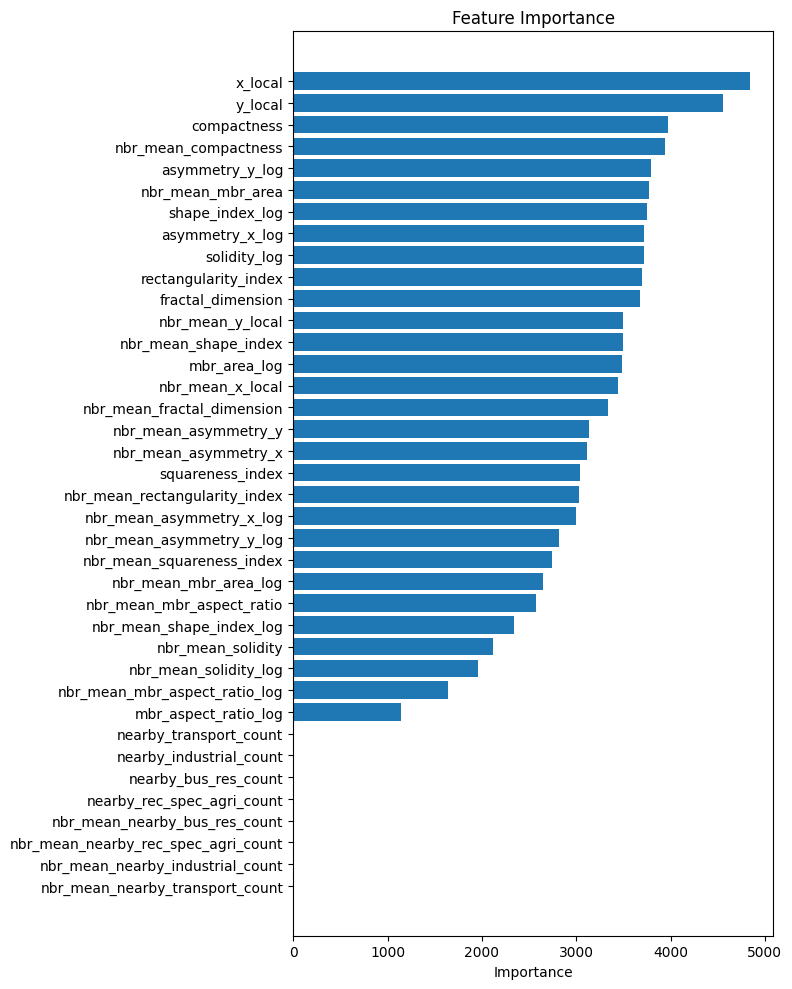

In [25]:
# df = pd.DataFrame([values], columns=columns)

df = pd.DataFrame({
    'feature': classifier.feature_cols,
    'importance': classifier.strategy.model.estimators_[2].feature_importances_
}).sort_values(by='importance', ascending=False).reset_index(drop=True)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 10))
plt.barh(df['feature'], df['importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## ------------------------------------------------------------

In [1]:
import pickle
import pandas as pd
import geopandas as gpd
from pathlib import Path

def load_gdfs(root: str | Path, pattern: str = "*.pkl", target_crs: str | None = None) -> list[gpd.GeoDataFrame]:
    """
    Загружает GeoDataFrame'ы из .pkl файлов:
      - если root указывает на один .pkl файл — читаем его и возвращаем список [GDF]
      - если root — папка — рекурсивно ищем по маске pattern и возвращаем список GDF

    Пытаемся заполнить столбцы 'city' и 'country' из структуры путей:
    .../<country>/<city>/<file>.pkl

    Args:
        root: путь к файлу .pkl или папке
        pattern: маска файлов (по умолчанию "*.pkl") — используется только если root папка
        target_crs: если указан, приводим все геоданные к этому CRS

    Returns:
        list[GeoDataFrame]
    """
    p = Path(root)

    def _ensure_gdf(obj):
        """Преобразует объект в GeoDataFrame, если это DataFrame с колонкой 'geometry'."""
        if isinstance(obj, gpd.GeoDataFrame):
            return obj
        if isinstance(obj, pd.DataFrame) and "geometry" in obj.columns:
            return gpd.GeoDataFrame(obj, geometry="geometry", crs=getattr(obj, "crs", None))
        return None

    def _infer_city_country(fp: Path):
        # ожидаем .../<country>/<city>/<file>.pkl
        city = fp.name[:-4] if fp else None
        country = fp.parent.name if len(fp.parents) >= 2 else None
        return city, country

    # Соберём список файлов
    if p.is_file() and p.suffix.lower() == ".pkl":
        files = [p]
    elif p.is_dir():
        files = sorted(p.rglob(pattern))
        files = [f for f in files if f.suffix.lower() == ".pkl"]
    else:
        return []

    gdfs: list[gpd.GeoDataFrame] = []

    for fp in files:
        try:
            with open(fp, "rb") as f:
                obj = pickle.load(f)
        except Exception as e:
            print(f"Пропускаю {fp}: {e}")
            continue

        # Если GeoDataFrame
        gdf = _ensure_gdf(obj)

        # Если dict с GeoDataFrame
        if gdf is None and isinstance(obj, dict):
            for k, v in obj.items():
                gi = _ensure_gdf(v)
                if gi is None:
                    continue
                gi = gi.copy()
                if "city" not in gi.columns or gi["city"].isna().all():
                    gi["city"] = str(k)
                _, country = _infer_city_country(fp)
                if ("country" not in gi.columns) and country:
                    gi["country"] = country
                if target_crs:
                    gi = gi.to_crs(target_crs) if gi.crs else gi.set_crs(target_crs)
                gdfs.append(gi)
            continue

        if gdf is None:
            print(f"Пропускаю {fp}: объект не GeoDataFrame и не dict с GeoDataFrame.")
            continue

        gdf = gdf.copy()
        city, country = _infer_city_country(fp)
        if "city" not in gdf.columns:
            gdf["city"] = city or fp.stem
        if ("country" not in gdf.columns) and country:
            gdf["country"] = country

        if target_crs:
            gdf = gdf.to_crs(target_crs) if gdf.crs else gdf.set_crs(target_crs)

        gdfs.append(gdf)

    return gdfs

blocks_gdf = load_gdfs('data/TANYA-2025/')
idk = [gpd.read_file('data/blocks_best_feature.gpkg')]

In [2]:
from blocksnet.analysis.land_use.prediction.core import str_to_land_use, land_use_to_category, category_to_index
from blocksnet.analysis.land_use.prediction.schemas import BlocksInputSchema
import pandas as pd

def normalize_and_filter(data):
    if isinstance(data, (list, tuple)):
        out = []
        for g in data:
            gi = BlocksInputSchema(g)
            if 'land_use' in gi:
                gi['category'] = gi['land_use'].map(str_to_land_use).map(land_use_to_category)
            gi = gi[gi['category'].map(category_to_index).notna()]
            if not gi.empty:
                out.append(gi)
        return out
    else:
        g = BlocksInputSchema(data)
        if 'land_use' in g:
            g['category'] = g['land_use'].map(str_to_land_use).map(land_use_to_category)
        return g[g['category'].map(category_to_index).notna()]

blocks_gdf_copy = normalize_and_filter(blocks_gdf)
idk = normalize_and_filter(idk)

d:\programming\github\blocksnet\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.spatial.distance import cdist
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from blocksnet.enums import LandUse, LandUseCategory

# blocks_list — список GeoDataFrame, один город = один элемент
# если у вас уже есть этот список, просто присвойте:
# blocks_list = my_city_gdfs

def map_land_use_category(value):
    if isinstance(value, LandUseCategory):
        return value
    if isinstance(value, LandUse):
        return LandUseCategory.from_land_use(value)
    if isinstance(value, str):
        try:
            lu = LandUse(value.lower())
        except ValueError:
            return None
        return LandUseCategory.from_land_use(lu)
    return None

# ---------- утилиты ----------
def polygon_holes_area(geom):
    if geom is None or geom.is_empty:
        return 0.0
    if geom.geom_type == "Polygon":
        # сумма площадей внутренних колец
        return sum(abs(poly.area) for poly in [geom] for ring in geom.interiors) if len(geom.interiors) else 0.0
    if geom.geom_type == "MultiPolygon":
        total = 0.0
        for part in geom.geoms:
            if len(part.interiors):
                total += sum(abs(poly.area) for poly in [part] for ring in part.interiors)
        return total
    return 0.0

def oriented_bbox_angle(rect):
    if rect.is_empty:
        return 0.0
    coords = list(rect.exterior.coords)
    if len(coords) < 2:
        return 0.0
    edge = np.array(coords[1]) - np.array(coords[0])
    angle = np.arctan2(edge[1], edge[0])
    if angle < -np.pi / 2:
        angle += np.pi
    if angle > np.pi / 2:
        angle -= np.pi
    return angle

def count_exterior_vertices(geom):
    if geom.is_empty:
        return 0
    if geom.geom_type == "Polygon":
        return max(0, len(geom.exterior.coords) - 1)  # минус закрывающий дублирующий узел
    if geom.geom_type == "MultiPolygon":
        return int(np.sum([max(0, len(p.exterior.coords) - 1) for p in geom.geoms]))
    return 0

def count_holes(geom):
    if geom.is_empty:
        return 0
    if geom.geom_type == "Polygon":
        return len(geom.interiors)
    if geom.geom_type == "MultiPolygon":
        return int(np.sum([len(p.interiors) for p in geom.geoms]))
    return 0

def safe_div(a, b, default=0.0):
    return np.where(b != 0, a / b, default)

# ---------- основной конструктор ----------
def build_geometry_features_for_cities(city_gdfs: list[gpd.GeoDataFrame], batch_size=2000) -> gpd.GeoDataFrame:
    pieces = []

    for idx, city_gdf in enumerate(city_gdfs):
        category = city_gdf.category
        city_name = city_gdf.get("city", pd.Series([f"city_{idx}"] * len(city_gdf)))
        city = city_gdf.copy().reset_index(drop=True)
        city["__city_id__"] = city_name if isinstance(city_name, pd.Series) else f"city_{idx}"

        geom = city.geometry
        # базовые
        area = geom.area
        perimeter = geom.length

        # выпуклая оболочка и МВО (минимальный повернутый прямоугольник)
        convex = geom.convex_hull
        convex_area = convex.area.replace(0, np.nan)
        mbr = geom.minimum_rotated_rectangle()
        mbr_area = mbr.area.replace(0, np.nan)
        mbr_bounds = mbr.bounds
        width = (mbr_bounds.maxx - mbr_bounds.minx).replace(0, np.nan)
        height = (mbr_bounds.maxy - mbr_bounds.miny).replace(0, np.nan)
        mbr_perimeter = 2 * (width + height)

        # ориентация
        orientation = pd.Series([oriented_bbox_angle(g) for g in mbr], index=city.index)
        orientation_sin = np.sin(orientation)
        orientation_cos = np.cos(orientation)

        # представительные точки для «локальных» расстояний
        reps = geom.representative_point()
        coords = np.column_stack((reps.x.values, reps.y.values)).astype(float)

        n = len(coords)
        median_dist = np.zeros(n)
        mean_k3_dist = np.zeros(n)  # среднее расстояние до 3 ближайших (без себя)
        if n > 1:
            for i in range(0, n, batch_size):
                batch = coords[i:i + batch_size]
                dist_block = cdist(batch, coords)
                # маскируем «самого себя»
                row_idx, col_idx = np.indices(dist_block.shape)
                self_mask = (col_idx >= i) & (col_idx < i + batch_size) & (row_idx == (col_idx - i))
                dist_block[self_mask] = np.nan

                median_dist[i:i + batch_size] = np.nanmedian(dist_block, axis=1)
                # k-NN (k=3)
                part = np.sort(dist_block, axis=1)[:, :3]
                mean_k3_dist[i:i + batch_size] = np.nanmean(part, axis=1)
        else:
            median_dist[:] = 0
            mean_k3_dist[:] = 0

        # ----- ДОПОЛНИТЕЛЬНЫЕ ПРИЗНАКИ ФОРМЫ -----

        # 1) Компактность/круглотность
        circularity = safe_div(4 * np.pi * area, perimeter ** 2, 0.0)              # Polsby–Popper
        thinness_ratio = safe_div(2 * np.sqrt(np.pi * area), perimeter, 0.0)       # Schwartzberg (обратная криволинейность)
        shape_index = safe_div(area, perimeter, 0.0)                                # у вас уже был — оставим

        # 2) MBR-признаки
        rectangularity = safe_div(area, mbr_area, 0.0)
        aspect_ratio = safe_div(np.maximum(width, height), np.minimum(width, height), 1.0)
        squareness = safe_div(np.minimum(width, height), np.maximum(width, height), 0.0)
        mbr_fill_ratio = safe_div(perimeter, mbr_perimeter.replace(0, np.nan), np.nan)  # насколько контур «длиннее» периметра MBR

        # 3) Выпуклость/впадины
        solidity = safe_div(area, convex_area, 0.0)
        concavity_ratio = 1 - solidity  # доля «потерь» к выпуклой оболочке
        convexity_index = safe_div(convex_area, area.replace(0, np.nan), np.nan)  # обратный solidity

        # 5) Эквивалентная окружность
        equiv_diameter = 2 * np.sqrt(area / np.pi)
        equiv_circumference = np.pi * equiv_diameter
        perimeter_to_equiv_circ = safe_div(perimeter, equiv_circumference.replace(0, np.nan), 0.0)

        # 6) Сложность контура
        vertices_exterior = pd.Series([count_exterior_vertices(g) for g in geom], index=city.index)
        perimeter_per_vertex = safe_div(perimeter, vertices_exterior.replace(0, np.nan), 0.0)

        # 7) Лог-версии и стабилизация масштаба
        area_log = np.log1p(area)
        perimeter_log = np.log1p(perimeter)
        mbr_area_log = np.log1p(mbr_area)
        convex_area_log = np.log1p(convex_area)
        shape_index_log = np.log1p(shape_index)
        # rectangularity_log = np.log1p(rectangularity)
        # aspect_ratio_log = np.log1p(aspect_ratio)
        # squareness_log = np.log1p(squareness)
        # solidity_log = np.log1p(solidity)
        # concavity_ratio_log = np.log1p(concavity_ratio)
        # convexity_index_log = np.log1p(convexity_index)
        equiv_diameter_log = np.log1p(equiv_diameter)
        # vertices_exterior_log = np.log1p(vertices_exterior)
        # perimeter_per_vertex_log = np.log1p(perimeter_per_vertex)
        median_dist_log = np.log1p(median_dist)
        mean_k3_dist_log = np.log1p(mean_k3_dist)

        # 8) «Фрактальность» (псевдо-оценка)
        # Чем больше отношение log(P)/log(A), тем «неровнее» граница (грубая метрика)
        with np.errstate(divide='ignore', invalid='ignore'):
            fractal_dimension = safe_div(np.log(perimeter.replace(0, np.nan)), np.log(area.replace(0, np.nan)), np.nan)

        # 9) Нормировки относительно MBR
        area_over_mbr_diag2 = safe_div(area, (width**2 + height**2).replace(0, np.nan), 0.0)
        perimeter_over_mbr_diag = safe_div(perimeter, np.sqrt((width**2 + height**2)).replace(0, np.nan), 0.0)

        # 10) Нормировки относительно выпуклой оболочки
        perimeter_over_convex_perimeter = safe_div(perimeter, convex.length.replace(0, np.nan), 0.0)

        # 11) Координаты центров (как чисто геометрические признаки положения)
        # cent_x = reps.x
        # cent_y = reps.y

        # собираем
        features = pd.DataFrame({
            "__city_id__": city["__city_id__"],

            # базовые
            "area": area,
            "perimeter": perimeter,

            # компактность/круглотность
            "circularity": circularity,
            "thinness_ratio": thinness_ratio,
            "shape_index": shape_index,

            # MBR
            "rectangularity": rectangularity,
            "aspect_ratio": aspect_ratio,
            "squareness": squareness,
            "mbr_fill_ratio": mbr_fill_ratio,

            # выпуклость/впадины
            "solidity": solidity,
            "concavity_ratio": concavity_ratio,
            "convexity_index": convexity_index,

            # эквивалентная окружность
            "equiv_diameter": equiv_diameter,
            "perimeter_to_equiv_circ": perimeter_to_equiv_circ,

            # сложность контура
            "vertices_exterior": vertices_exterior.astype(float),
            "perimeter_per_vertex": perimeter_per_vertex,

            # ориентация
            "orientation_sin": orientation_sin,
            "orientation_cos": orientation_cos,

            # «локальные» расстояния
            "median_dist_representative": median_dist,
            "mean_k3_dist": mean_k3_dist,

            # нормировки/логи
            "fractal_dimension": fractal_dimension,
            "area_over_mbr_diag2": area_over_mbr_diag2,
            "perimeter_over_mbr_diag": perimeter_over_mbr_diag,
            # "perimeter_over_convex_perimeter": perimeter_over_convex_perimeter,

            # координаты центров (геометрия → положение)
            # "centroid_x": cent_x,
            # "centroid_y": cent_y,

            # целевая метка
            "category": category
        }, index=city.index)

        features["geometry"] = geom
        pieces.append(features)

    return gpd.GeoDataFrame(pd.concat(pieces, ignore_index=True), geometry="geometry")


# Применяем
geometry_features = build_geometry_features_for_cities(blocks_gdf_copy)
geometry_features.dropna(inplace=True)
dataset = geometry_features.copy()
dataset["category"] = geometry_features["category"].astype("category").cat.codes
label_mapping = dict(enumerate(geometry_features["category"].astype("category").cat.categories))

In [4]:
# --- Очистка, фильтрация и подготовка выборки для обучения ---
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import compute_class_weight
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd

# 4. Универсальное удаление выбросов по IQR
num_cols = dataset.select_dtypes(include=[np.number]).columns.drop(["category"])
clean = dataset.copy()
for col in num_cols:
    Q1, Q3 = clean[col].quantile([0.01, 0.99])
    IQR = Q3 - Q1
    low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    clean = clean[(clean[col] >= low) & (clean[col] <= high)]


In [5]:
# 6. Масштабирование
X = clean.drop(columns=["category", "geometry", "__city_id__"])
y = clean["category"].to_numpy()

scaler = StandardScaler()
X = scaler.fit_transform(X)

# 7. Балансировка классов (SMOTE)
# smote = SMOTE(random_state=42, k_neighbors=3)
# X_bal, y_bal = smote.fit_resample(X_scaled, y)

In [6]:
clean['category'].value_counts()

category
0    1173302
1     113042
3      74588
2      46025
Name: count, dtype: int64

In [7]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42, sampling_strategy={0: int(len(y[y==2]) * 1.2)})
X, y = rus.fit_resample(X, y)

# 8. Разделение train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 9. Веса классов
classes = np.unique(y_train)
class_weights_vec = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights = dict(zip(classes, class_weights_vec))
class_weights_readable = {label_mapping[k].name: float(v.round(2)) for k, v in class_weights.items()}

print("Class weights:", class_weights_readable)
print(f"Финальная выборка: {X_train.shape[0]} train / {X_test.shape[0]} test / {len(classes)} классов")

Class weights: {'RESIDENTIAL': 1.31, 'INDUSTRIAL': 0.64, 'BUSINESS': 1.57, 'RECREATION': 0.97}
Финальная выборка: 216663 train / 72222 test / 4 классов


In [8]:
from sklearn.ensemble import VotingClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix

# --- Базовые модели ---
estimators = [
    ("rf", RandomForestClassifier(
        n_estimators=400,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )),
    ("xgb", XGBClassifier(
        n_estimators=600,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        eval_metric="mlogloss",
        n_jobs=8,
        random_state=42
    )),
    ("lgb", LGBMClassifier(
        n_estimators=800,
        max_depth=10,
        learning_rate=0.05,
        class_weight="balanced",
        num_threads=8,
        random_state=42
    )),
    ("hgb", HistGradientBoostingClassifier(
        max_iter=500,
        max_depth=8,
        learning_rate=0.05,
        random_state=42
    )),
]

# --- Ансамбль ---
model = VotingClassifier(
    estimators=estimators,
    voting="soft",          # усреднение вероятностей (лучше, чем majority vote)
    weights=[1, 1.5, 1.5, 1],  # можно скорректировать веса, если LGB/XGB дают лучшую валидацию
    n_jobs=-1
)

model.fit(X_train, y_train)

,estimators,"[('rf', ...), ('xgb', ...), ...]"
,voting,'soft'
,weights,"[1, 1.5, ...]"
,n_jobs,-1
,flatten_transform,True
,verbose,False
,n_estimators,400
,criterion,'gini'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,5


In [9]:
y_pred = model.predict(X_test)

d:\programming\github\blocksnet\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Classification report:

              precision    recall  f1-score   support

 RESIDENTIAL       0.45      0.31      0.37     13808
  INDUSTRIAL       0.50      0.74      0.59     28261
    BUSINESS       0.29      0.10      0.15     11506
  RECREATION       0.41      0.37      0.39     18647

    accuracy                           0.46     72222
   macro avg       0.41      0.38      0.38     72222
weighted avg       0.43      0.46      0.43     72222



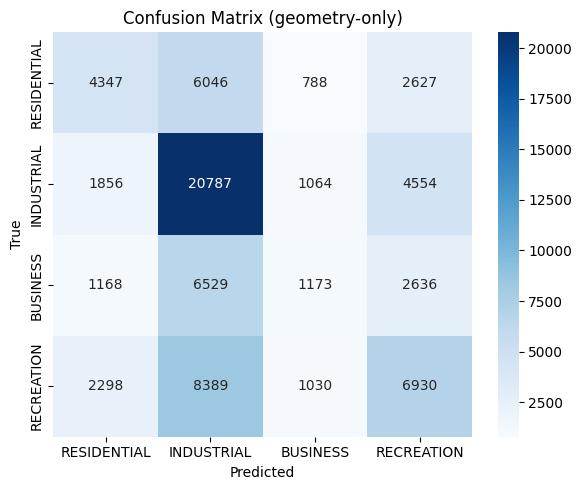

In [10]:
print("Classification report:\n")
print(classification_report(y_test, y_pred, target_names=[label_mapping[c].name for c in classes]))

cm = confusion_matrix(y_test, y_pred, labels=classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=[label_mapping[c].name for c in classes],
            yticklabels=[label_mapping[c].name for c in classes],
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (geometry-only)")
plt.tight_layout()
plt.show()

# rf_feature_importances = model.named_steps["rf"].feature_importances_
# feat_imp = pd.Series(rf_feature_importances, index=X.columns).sort_values(ascending=False)
# plt.figure(figsize=(8, 5))
# feat_imp.plot(kind="barh")
# plt.gca().invert_yaxis()
# plt.title("Top geometry features by importance")
# plt.tight_layout()
# plt.show()

In [11]:
probs = model.predict_proba(X_test)
print(np.mean(probs, axis=0))  # средние вероятности по классам


d:\programming\github\blocksnet\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[0.21484366 0.32942534 0.20117678 0.25455422]


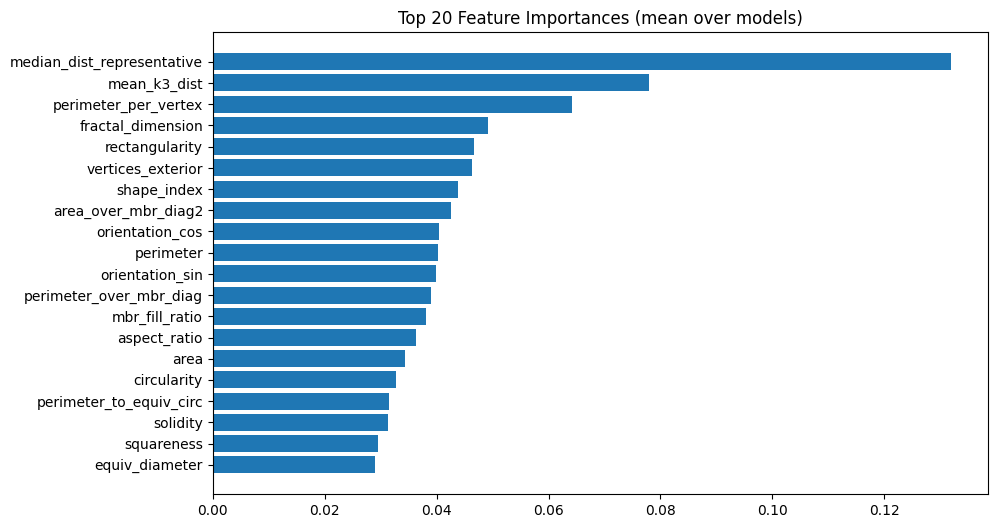

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# усредняем важности по моделям, где они доступны
importances = []
names = clean.drop(columns=["category", "geometry", "__city_id__"]).columns

for name, est in model.named_estimators_.items():
    if hasattr(est, "feature_importances_"):
        imp = est.feature_importances_
        # Нормализуем важности для каждой модели
        if imp.sum() > 0:
            imp = imp / imp.sum()  # нормализуем к сумме 1.0
        importances.append(imp)

mean_importance = np.mean(importances, axis=0)
importance_df = pd.DataFrame({"feature": names, "importance": mean_importance})
importance_df.sort_values("importance", ascending=False, inplace=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df.feature.head(20), importance_df.importance.head(20))
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances (mean over models)")
plt.show()


